In [1]:
import pandas as pd
import numpy as np
from econml.dml import LinearDML
from xgboost import XGBRegressor, XGBClassifier
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
THRESHOLDS = [15, 30, 60, 120]
# 6-hour increments over 48 hours
TIME_BINS = np.arange(0, 49, 6) 
LABELS = [f"{i}-{i+6}h" for i in range(0, 48, 6)]

# --- 2. DATA LOADING & CLEANING ---
master_df = pd.read_parquet('data/flight_data.parquet')

C:\Users\LAltringer\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df = master_df[(master_df['strike_damage'] == 1) & 
               (master_df['strike_arrival_departure'] == 'Arrival')].copy()

# Calculate each flights distance from the effective timing of the associated strike event
df['scheduled_departure_datetime'] = pd.to_datetime(df['scheduled_departure_datetime'], format='mixed')
df['strike_date_time'] = pd.to_datetime(df['strike_date_time'], format='mixed')
df['hours_from_strike'] = (df['scheduled_departure_datetime'] - df['strike_date_time']).dt.total_seconds() / 3600

# Define if a flight is operated by the same airline to which the strike occurred
df['is_strike_airline'] = (df['carrier_code'] == df['strike_airline']).astype(int)

# Define Treatment (T): Flight is post-strike AND flown by the strike airline
df['T'] = (df['carrier_code'] == df['strike_airline']).astype(int)

# Define Time Segments for Heterogeneity (X)
df['time_segment'] = pd.cut(df['hours_from_strike'], bins=TIME_BINS, labels=LABELS)
df['time_segment'] = df['time_segment'].cat.add_categories(['Control']).fillna('Control')

# Create binary outcome variables
for t in THRESHOLDS:
    df[f'delay_gt_{t}'] = (df['departure_delay_minutes'] > t).astype(int)

# Create temporal fixed effect components
df['hour'] = df['scheduled_departure_datetime'].dt.hour
df['year'] = df['scheduled_departure_datetime'].dt.year
df['month'] = df['scheduled_departure_datetime'].dt.month
df['day_of_week'] = df['scheduled_departure_datetime'].dt.dayofweek

# Create the interaction fixed effect (Airport ^ Carrier)
# Example: 'JFK_DL' or 'ORD_UA'
df['airport_carrier'] = df['airport'].astype(str) + "_" + df['carrier_code'].astype(str)

# --- 4. MATRIX PREPARATION ---
# X: Variables that modify the effect (Time distance and Strike Type)
# We drop 'Control' from dummies so the baseline is "Pre-strike"
X_raw = df[['time_segment']]
X = pd.get_dummies(X_raw, drop_first=True)

# Define the fixed effect columns
fe_cols = ['hour', 'year', 'month', 'day_of_week', 'airport_carrier']

# Combine Weather and Fixed Effects
# We use drop_first=True to prevent multi-collinearity
W_fe = pd.get_dummies(df[fe_cols], columns=fe_cols, drop_first=True, sparse=True)

# Combine with continuous weather variables
W_weather = df[['temp', 'visibility', 'windspeed', 'precip', 'humidity']].fillna(0)
W = pd.concat([W_weather, W_fe], axis=1)

# T: Treatment
T = df['T']

# --- 5. CAUSAL MODELING LOOP ---
results = {}

for t in THRESHOLDS[1:2]:
    Y = df[f'delay_gt_{t}']
    
    print(f"--- Estimating Causal Impact for Delay > {t} mins ---")
    
    # LinearDML is efficient for large datasets and provides interpretable effects per bin
    est = LinearDML(
        model_y=XGBRegressor(max_depth=3, n_estimators=100), 
        model_t=XGBClassifier(max_depth=3, n_estimators=100),
        discrete_treatment=True,
        cv=3 # 3-fold cross-fitting for robustness
    )
    
    # Fit the model
    est.fit(Y, T, X=X, W=W)
    results[t] = est

# --- 6. SUMMARY OF RESULTS ---
for t, model in results.items():
    print(f"\nResults for {t} minute threshold:")
    # This will show the coefficient for each time_segment bin
    display(model.summary())

--- Estimating Causal Impact for Delay > 30 mins ---


C:\Users\LAltringer\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(



Results for 30 minute threshold:


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
time_segment_6-12h,-0.052,0.012,-4.428,0.0,-0.075,-0.029
time_segment_12-18h,-0.053,0.01,-5.05,0.0,-0.073,-0.032
time_segment_18-24h,-0.061,0.011,-5.794,0.0,-0.081,-0.04
time_segment_24-30h,-0.064,0.012,-5.52,0.0,-0.087,-0.041
time_segment_30-36h,-0.063,0.012,-5.472,0.0,-0.086,-0.04
time_segment_36-42h,-0.07,0.01,-6.766,0.0,-0.09,-0.05
time_segment_42-48h,-0.072,0.01,-6.88,0.0,-0.092,-0.051
time_segment_Control,-0.071,0.009,-7.924,0.0,-0.088,-0.053
,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
cate_intercept,0.071,0.009,8.23,0.0,0.054,0.088


In [28]:
import pandas as pd
import numpy as np
from linearmodels.iv import AbsorbingLS

# --- 1. CONFIGURATION & DATA LOADING ---
INPUT_PATH = 'data/flight_data.parquet'
DV = 'delay_gt_120'  # Your dependent variable threshold
CONTROLS = ['temp', 'visibility', 'windspeed', 'precip', 'humidity']

print("Loading data...")
master_df = pd.read_parquet(INPUT_PATH)

# --- 2. SUBSETTING (Damaging Arrival Strikes) ---
# Logic: Damaging strikes occurring during arrival (the inbound shock)
df = master_df[(master_df['strike_damage'] == 1) & 
               (master_df['strike_arrival_departure'] == 'Arrival')].copy()

# --- RE-DEFINE BINARY OUTCOMES ---
# Define the thresholds you want to test
THRESHOLDS = [15, 30, 60, 120]

for t in THRESHOLDS:
    # This creates the 'delay_gt_15', 'delay_gt_30', etc. columns
    df[f'delay_gt_{t}'] = (df['departure_delay_minutes'] > t).astype(int)

# Double check the column is there now
print(f"Verified columns: {[col for col in df.columns if 'delay_gt' in col]}")

# --- 3. DATETIME & TEMPORAL FIXED EFFECTS ---
df['scheduled_departure_datetime'] = pd.to_datetime(df['scheduled_departure_datetime'], format='mixed')
df['strike_date_time'] = pd.to_datetime(df['strike_date_time'], format='mixed')

# Fixed Effect Components
df['hour'] = df['scheduled_departure_datetime'].dt.hour
df['year'] = df['scheduled_departure_datetime'].dt.year
df['month'] = df['scheduled_departure_datetime'].dt.month
df['day_of_week'] = df['scheduled_departure_datetime'].dt.dayofweek
df['airport_carrier'] = df['airport'].astype(str) + "_" + df['carrier_code'].astype(str)

# --- 4. EVENT STUDY VARIABLE ENGINEERING ---
# Positive = Post-strike (Lags), Negative = Pre-strike (Leads)
df['hours_from_strike'] = (df['scheduled_departure_datetime'] - df['strike_date_time']).dt.total_seconds() / 3600
df['is_strike_airline'] = (df['carrier_code'] == df['strike_airline']).astype(int)

# Create 4-hour bins for 48 hours before and after
h = df['hours_from_strike']
is_same = df['is_strike_airline'] == 1

lag_cols = []
lead_cols = []

# Create Lags (Post-Strike 1-12)
for i in range(1, 13):
    col = f'lag{i}'
    df[col] = np.where((h > (i-1)*4) & (h <= i*4) & is_same, 1, 0)
    lag_cols.append(col)

# Create Leads (Pre-Strike 1-12)
for i in range(1, 13):
    col = f'lead{i}'
    df[col] = np.where((h < -(i-1)*4) & (h >= -i*4) & is_same, 1, 0)
    lead_cols.append(col)

# --- 5. PREPARE MATRICES ---
# We omit 'lead1' as the reference category (the 4 hours immediately before strike)
# This ensures coefficients are interpreted relative to the period right before the hit.
exog_cols = lag_cols + lead_cols[1:]
exog = df[exog_cols + CONTROLS].fillna(0)

# Variables to absorb (High-dimensional Fixed Effects)
absorb_df = df[['airport_carrier', 'hour', 'year', 'month', 'day_of_week']].copy()
for col in absorb_df.columns:
    absorb_df[col] = absorb_df[col].astype('category')

# --- 6. RUN FIXED EFFECTS REGRESSION ---
print(f"Running AbsorbingLS Regression on {len(df)} observations...")
model = AbsorbingLS(
    dependent=df[DV].astype(float),
    exog=exog,
    absorb=absorb_df
)

results = model.fit(cov_type='heteroskedastic')

# --- 7. OUTPUT ---
print(results.summary)

Loading data...
Verified columns: ['delay_gt_15', 'delay_gt_30', 'delay_gt_60', 'delay_gt_120']
Running AbsorbingLS Regression on 463125 observations...
                         Absorbing LS Estimation Summary                          
Dep. Variable:           delay_gt_120   R-squared:                          0.0221
Estimator:               Absorbing LS   Adj. R-squared:                     0.0195
No. Observations:              463125   F-statistic:                        929.48
Date:                Wed, Jan 28 2026   P-value (F-stat):                   0.0000
Time:                        15:43:56   Distribution:                     chi2(28)
Cov. Estimator:       heteroskedastic   R-squared (No Effects):             0.0039
                                        Variables Absorbed:                 1189.0
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------

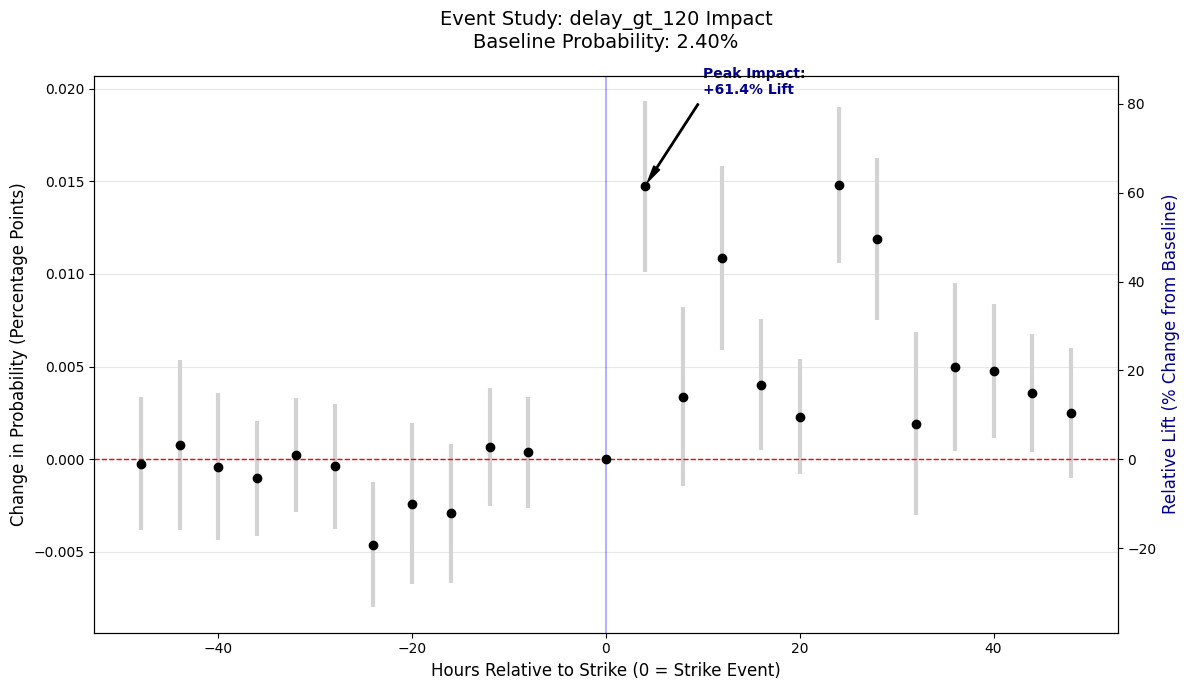

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- NEW: Calculate Baseline Mean for Lift Calculation ---
# We use the mean of the strike airline BEFORE the strike (all leads) 
# or the non-strike airlines as the baseline. 
baseline_mean = df[df['is_strike_airline'] == 0][DV].mean()

# 1. Extract coefficients and confidence intervals
params = results.params
conf_int = results.conf_int()

# 2. Define the timeline (X-axis)
timeline = {
    **{f'lead{i}': -i * 4 for i in range(12, 1, -1)},
    'lead1': 0,  
    **{f'lag{i}': i * 4 for i in range(1, 13)}
}

# 3. Build a plotting DataFrame
plot_data = []
for var, hour in timeline.items():
    if var == 'lead1':
        plot_data.append({'hour': hour, 'coef': 0, 'lower': 0, 'upper': 0})
    elif var in params:
        plot_data.append({
            'hour': hour, 
            'coef': params[var], 
            'lower': conf_int.loc[var, 'lower'], 
            'upper': conf_int.loc[var, 'upper']
        })

plot_df = pd.DataFrame(plot_data).sort_values('hour')

# 4. Create the Plot
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot the primary data (Percentage Points)
ax1.errorbar(plot_df['hour'], plot_df['coef'], 
             yerr=[plot_df['coef'] - plot_df['lower'], plot_df['upper'] - plot_df['coef']],
             fmt='o', color='black', ecolor='lightgray', elinewidth=3, capsize=0, label='Estimate (95% CI)')

# --- NEW: Add the Relative Lift Axis (Right Side) ---
ax2 = ax1.twinx()
# Set the limits of ax2 to match the relative lift of the limits on ax1
y1_min, y1_max = ax1.get_ylim()
ax2.set_ylim(y1_min / baseline_mean * 100, y1_max / baseline_mean * 100)

# Aesthetics
ax1.axhline(0, color='red', linestyle='--', linewidth=1)
ax1.axvline(0, color='blue', linestyle='-', alpha=0.3)

ax1.set_title(f'Event Study: {DV} Impact\nBaseline Probability: {baseline_mean:.2%}', fontsize=14, pad=20)
ax1.set_xlabel('Hours Relative to Strike (0 = Strike Event)', fontsize=12)
ax1.set_ylabel('Change in Probability (Percentage Points)', fontsize=12)
ax2.set_ylabel('Relative Lift (% Change from Baseline)', fontsize=12, color='darkblue')

# Annotate the max impact (Lag 1) with the Lift %
max_lag = plot_df[plot_df['hour'] == 4].iloc[0]
lift_val = (max_lag['coef'] / baseline_mean) * 100
ax1.annotate(f'Peak Impact:\n+{lift_val:.1f}% Lift', 
             xy=(4, max_lag['coef']), xytext=(10, max_lag['coef'] + 0.005),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, fontweight='bold', color='darkblue')

ax1.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

In [ ]:
# 3. Create the Plot
plt.figure(figsize=(12, 6))

# Histogram with 1-hour bins
n, bins, patches = plt.hist(
    df['hours_from_strike'], 
    bins=96, 
    range=(-48, 48), 
    color='#3498db', 
    edgecolor='white', 
    alpha=0.8
)

# Add a vertical line at T=0 (The Strike Event)
plt.axvline(x=0, color='#e74c3c', linestyle='--', linewidth=2, label='Strike Event (T=0)')

# Formatting
plt.title('Frequency of Flights Relative to Strike Timing', fontsize=14, fontweight='bold')
plt.xlabel('Hours from Strike (Negative = Pre-Strike, Positive = Post-Strike)', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)
plt.xticks(np.arange(-48, 49, 6)) # Markers every 6 hours to match your bins
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()